# Guia 4 - Aprendizaje no supervisado

**Objetivo:** preparar un dataset y aplicar clustering para descubrir segmentos de clientes.

En esta guia no se usa variable objetivo `y`. La variable `Abandono` no se utiliza para entrenar los clusters.

In [1]:
# ============================================================
# 1. Importar librerias
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print('Librerias cargadas correctamente')

Librerias cargadas correctamente


In [2]:
# ============================================================
# 2. Cargar dataset
# ============================================================
from pathlib import Path

rutas_posibles = [
    Path('G4_base_clientes.csv'),
    Path('../03_dataset/G4_base_clientes.csv'),
    Path('/mnt/data/G4_base_clientes.csv')
]

for ruta in rutas_posibles:
    if ruta.exists():
        df = pd.read_csv(ruta)
        print('Dataset cargado desde:', ruta)
        break
else:
    raise FileNotFoundError('No se encontro G4_base_clientes.csv. Revise la ubicacion del dataset.')

print('Dimensiones:', df.shape)
df.head()

Dataset cargado desde: G4_base_clientes.csv
Dimensiones: (420, 18)


,ID_Cliente,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion,CodigoCampania,Abandono
0,CLI_0001,18,3968,17,5,4,0,39,11,7.72,1,Cali,Tienda,Urbana,Basico,Media,CAMP_10,0
1,CLI_0002,50,3528,18,8,53,1,12,1,5.50,1,Medellin,Telefono,Urbana,Basico,Alta,CAMP_04,0
2,CLI_0003,46,750,16,8,90,1,83,10,6.15,3,Cartagena,Web,Urbana,Basico,Alta,CAMP_09,0
3,CLI_0004,20,4356,21,4,25,3,85,4,10.88,2,Cartagena,Tienda,Rural,Medio,Baja,CAMP_06,1
4,CLI_0005,61,6155,12,4,10,0,21,6,0.51,2,Bogota,Tienda,Urbana,Medio,Alta,CAMP_01,0


## 3. Diagnostico inicial
Revise tipos de datos, valores nulos, duplicados y valores unicos de variables categoricas.

In [3]:
# Complete y ejecute el diagnostico
print(df.info())
print("\nNulos por columna:")
print(df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())
print("\nValores de Segmento:", df['Segmento'].unique())
print("Valores de Satisfaccion:", df['Satisfaccion'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               420 non-null    object 
 1   Edad                     420 non-null    int64  
 2   IngresoMensual           420 non-null    int64  
 3   CantidadCompras          420 non-null    int64  
 4   ComprasUltimos12M        420 non-null    int64  
 5   AntiguedadMeses          420 non-null    int64  
 6   QuejasUltimos6M          420 non-null    int64  
 7   DiasDesdeUltimaCompra    420 non-null    int64  
 8   VisitasWebUltimoMes      420 non-null    int64  
 9   TiempoPromedioSesionMin  420 non-null    float64
 10  CuponesUsados            420 non-null    int64  
 11  Ciudad                   420 non-null    object 
 12  CanalPreferido           420 non-null    object 
 13  ZonaResidencia           420 non-null    object 
 14  Segmento                 4

## 4. Seleccion de variables
Seleccione variables que representen comportamiento o caracteristicas utiles para segmentar. No incluya `ID_Cliente` ni use `Abandono` como objetivo.

In [4]:
variables_cluster = [
    'Edad', 'IngresoMensual', 'CantidadCompras', 'ComprasUltimos12M',
    'AntiguedadMeses', 'QuejasUltimos6M', 'DiasDesdeUltimaCompra',
    'VisitasWebUltimoMes', 'TiempoPromedioSesionMin', 'CuponesUsados',
    'Ciudad', 'CanalPreferido', 'ZonaResidencia', 'Segmento', 'Satisfaccion'
]

X_cluster = df[variables_cluster].copy()
X_cluster.head()

,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion
0,18,3968,17,5,4,0,39,11,7.72,1,Cali,Tienda,Urbana,Basico,Media
1,50,3528,18,8,53,1,12,1,5.50,1,Medellin,Telefono,Urbana,Basico,Alta
2,46,750,16,8,90,1,83,10,6.15,3,Cartagena,Web,Urbana,Basico,Alta
3,20,4356,21,4,25,3,85,4,10.88,2,Cartagena,Tienda,Rural,Medio,Baja
4,61,6155,12,4,10,0,21,6,0.51,2,Bogota,Tienda,Urbana,Medio,Alta


## 5. Preprocesamiento
K-Means usa distancias. Por eso se escalan numericas y se codifican categoricas.

In [5]:
columnas_numericas = [
    'Edad', 'IngresoMensual', 'CantidadCompras', 'ComprasUltimos12M',
    'AntiguedadMeses', 'QuejasUltimos6M', 'DiasDesdeUltimaCompra',
    'VisitasWebUltimoMes', 'TiempoPromedioSesionMin', 'CuponesUsados'
]

columnas_nominales = ['Ciudad', 'CanalPreferido', 'ZonaResidencia']
columnas_ordinales = ['Segmento', 'Satisfaccion']

# Compatibilidad con versiones de scikit-learn
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocesador_cluster = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('nom', onehot, columnas_nominales),
        ('ord', OrdinalEncoder(
            categories=[['Basico', 'Medio', 'Premium'], ['Baja', 'Media', 'Alta']],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), columnas_ordinales)
    ]
)

X_preparado = preprocesador_cluster.fit_transform(X_cluster)
print('Matriz preparada:', X_preparado.shape)

Matriz preparada: (420, 24)


## 6. Metodo del codo
Pruebe diferentes valores de k y observe la inercia.

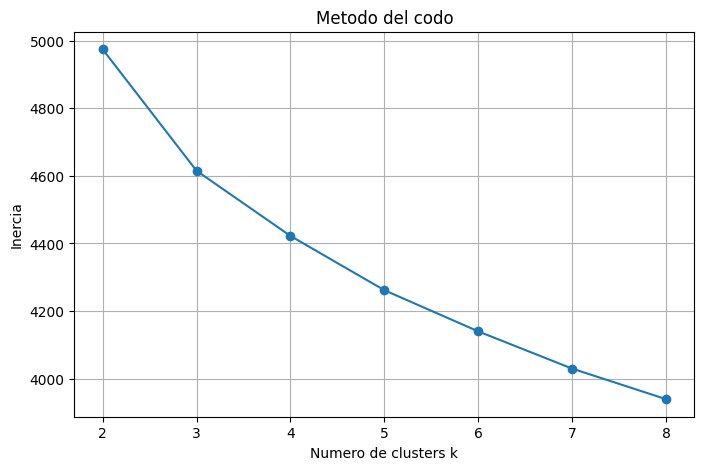

,k,inercia
0,2,4974.433682
1,3,4615.081176
2,4,4422.226149
3,5,4261.723426
4,6,4139.848592
5,7,4029.712251
6,8,3939.328466


In [ ]:
inercias = [] 
rango_k = range(2, 9)

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_preparado)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(rango_k), inercias, marker='o')
plt.title('Metodo del codo')
plt.xlabel('Numero de clusters k')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

pd.DataFrame({'k': list(rango_k), 'inercia': inercias})

## 7. Silhouette score
Calcule silhouette para varios valores de k.

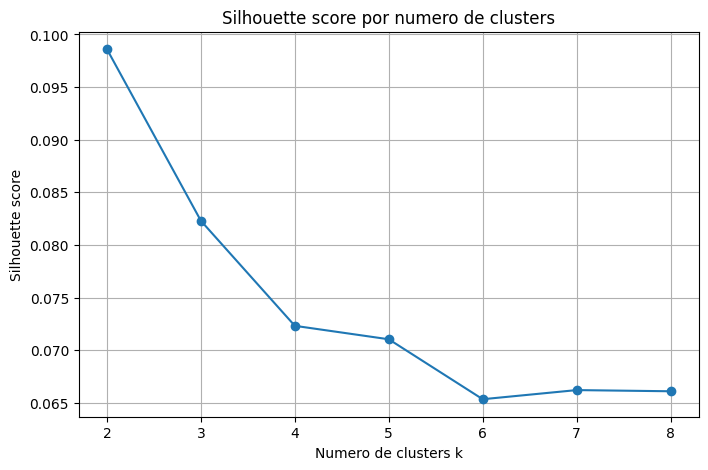

,k,silhouette
0,2,0.098598
1,3,0.082294
2,4,0.072314
3,5,0.071036
4,6,0.065339
5,7,0.066207
6,8,0.066095


In [7]:
silhouettes = []
for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_preparado)
    sil = silhouette_score(X_preparado, etiquetas)
    silhouettes.append(sil)

plt.figure(figsize=(8,5))
plt.plot(list(rango_k), silhouettes, marker='o')
plt.title('Silhouette score por numero de clusters')
plt.xlabel('Numero de clusters k')
plt.ylabel('Silhouette score')
plt.grid(True)
plt.show()

pd.DataFrame({'k': list(rango_k), 'silhouette': silhouettes})

## 8. Entrenar modelo final de clustering
Seleccione un valor de `k_optimo` con base en el codo, silhouette y sentido de negocio.

In [8]:
k_optimo = 3  # Ajuste este valor segun su analisis

modelo_kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = modelo_kmeans.fit_predict(X_preparado)

df_segmentado = df.copy()
df_segmentado['Cluster'] = clusters

print(df_segmentado['Cluster'].value_counts().sort_index())
df_segmentado.head()

Cluster
0    161
1    106
2    153
Name: count, dtype: int64


,ID_Cliente,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion,CodigoCampania,Abandono,Cluster
0,CLI_0001,18,3968,17,5,4,0,39,11,7.72,1,Cali,Tienda,Urbana,Basico,Media,CAMP_10,0,0
1,CLI_0002,50,3528,18,8,53,1,12,1,5.50,1,Medellin,Telefono,Urbana,Basico,Alta,CAMP_04,0,2
2,CLI_0003,46,750,16,8,90,1,83,10,6.15,3,Cartagena,Web,Urbana,Basico,Alta,CAMP_09,0,2
3,CLI_0004,20,4356,21,4,25,3,85,4,10.88,2,Cartagena,Tienda,Rural,Medio,Baja,CAMP_06,1,1
4,CLI_0005,61,6155,12,4,10,0,21,6,0.51,2,Bogota,Tienda,Urbana,Medio,Alta,CAMP_01,0,0


## 9. Perfilamiento de clusters
Calcule promedios por cluster e interprete los segmentos.

In [9]:
perfil_numerico = df_segmentado.groupby('Cluster')[columnas_numericas].mean().round(2)
perfil_numerico

,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados
Cluster,,,,,,,,,,
0,41.40,2957.65,11.91,5.17,26.98,0.61,34.61,9.97,7.26,3.10
1,37.08,3136.82,14.75,4.45,42.33,2.82,66.98,8.20,7.03,2.29
2,42.18,2957.60,21.22,5.35,71.67,0.81,36.44,9.37,6.95,2.16


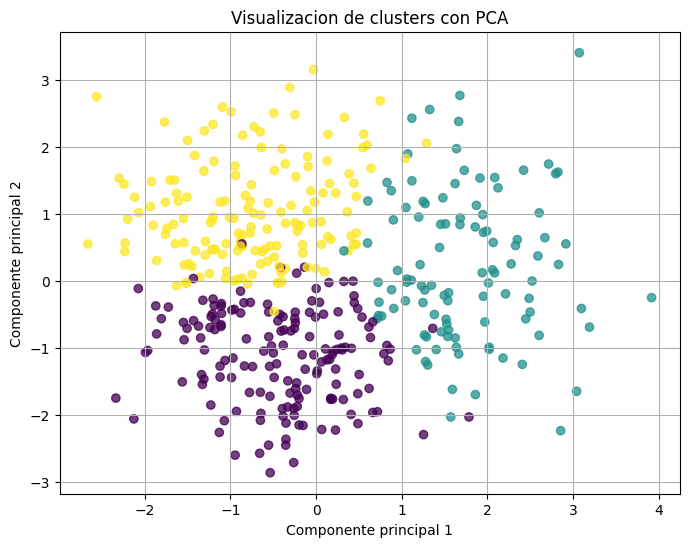

In [10]:
# Visualizacion 2D con PCA
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X_preparado)

plt.figure(figsize=(8,6))
plt.scatter(componentes[:,0], componentes[:,1], c=clusters, alpha=0.75)
plt.title('Visualizacion de clusters con PCA')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.grid(True)
plt.show()

## 10. Exportar dataset segmentado
Al final exporte el dataset con la columna Cluster.

In [11]:
df_segmentado.to_csv('G4_dataset_segmentado.csv', index=False, encoding='utf-8-sig')
print('Dataset segmentado exportado como G4_dataset_segmentado.csv')

Dataset segmentado exportado como G4_dataset_segmentado.csv


## 11. Preguntas de analisis
1. Que valor de k selecciono y por que?

R = Se seleccionó k = 3 porque presenta un equilibrio adecuado entre el método del codo y la interpretación de negocio. Aunque el valor más alto de silhouette fue para k = 2 (0.0986), con k = 3 se obtienen grupos más diferenciados y útiles para segmentar clientes en estrategias comerciales distintas


2. Que cluster representa clientes mas activos?

R = El Cluster 2 representa los clientes más activos, ya que tiene el promedio más alto de CantidadCompras (21.22) y también uno de los valores más altos en ComprasUltimos12M (5.35).

3. Que cluster puede requerir atencion comercial?

R = El Cluster 0 puede requerir mayor atención comercial porque presenta el menor nivel de actividad de compra, con un promedio de 11.91 compras, lo que puede indicar clientes menos comprometidos o con riesgo de disminuir su relación con la empresa.

4. Que variables ayudan a diferenciar mejor los grupos?

R = Las variables que más contribuyen a diferenciar los clusters son:
CantidadCompras
ComprasUltimos12M
IngresoMensual
Edad
AntiguedadMeses
DiasDesdeUltimaCompra

5. Que limitaciones tiene el analisis?

R = Algunas limitaciones del análisis son:

El algoritmo K-Means requiere definir previamente el número de clusters.
Los resultados dependen del proceso de escalamiento y transformación de variables.
El valor de silhouette obtenido es relativamente bajo, lo que indica que la separación entre grupos no es muy fuerte.
Los clusters encontrados representan patrones generales y no garantizan que todos los clientes dentro de un grupo tengan exactamente el mismo comportamiento.